## VQEC (Variational Quantum Eigensolver with Constraints)

Based on arXiv:2311.08502.

With the perturbed primal-dual (PPD) method, each VQE iteration consists of four steps. The first two steps involve the generation of the perturbed primal and dual variables (i.e., VQE parameters and Lagrange multipliers):
$$
\begin{split}
\tilde{\boldsymbol{\theta}}^t &= \boldsymbol{\theta}^t - \nu_\theta \sum_{m=0}^M \lambda_m^t \nabla_{\boldsymbol{\theta}} F_m(\boldsymbol{\theta}^t), \\
\tilde{\lambda}_m^t &= \left[\lambda_m^t + \nu_\lambda F_m(\boldsymbol{\theta}^t)\right]_+, \qquad m = 1:M.
\end{split}
$$
It is then followed by the computation of the updated primal and dual variables:
$$
\begin{split}
\boldsymbol{\theta}^{t+1} &= \boldsymbol{\theta}^t - \mu_\theta^t \sum_{m=0}^M \tilde{\lambda}_m^t \nabla_{\boldsymbol{\theta}} F_m(\boldsymbol{\theta}^t), \\
\lambda_m^{t+1} &= \left[\lambda_m^t + \mu_\lambda^t F_m(\tilde{\boldsymbol{\theta}}^t)\right]_+, \qquad m = 1:M.
\end{split}.

In [85]:
from qiskit.circuit.library import TwoLocal, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [65]:
def get_expectation(observable, circuit, parameter_values):
    return estimator.run(circuit, observable, parameter_values).result().values[0]

In [28]:
# Objective function (4 qubits)
obj_op = SparsePauliOp.from_list([("IIII", 1), ("ZIII", 0.7), ("IZII", 0.2), ("IZZI", 0.3), ("IZIZ", 0.5)])

# Some cooked up constraints
constr_op_1 = SparsePauliOp.from_list([("IZZZ", 5), ("ZIZZ", 3), ("ZZIZ", 4), ("ZZZI", 2)])
constr_op_2 = SparsePauliOp.from_list([("ZZII", 8)])
constr_op_3 = SparsePauliOp.from_list([("ZIIZ", 3), ("IZZI", 3)])
constr_ops = [constr_op_1, constr_op_2, constr_op_3]

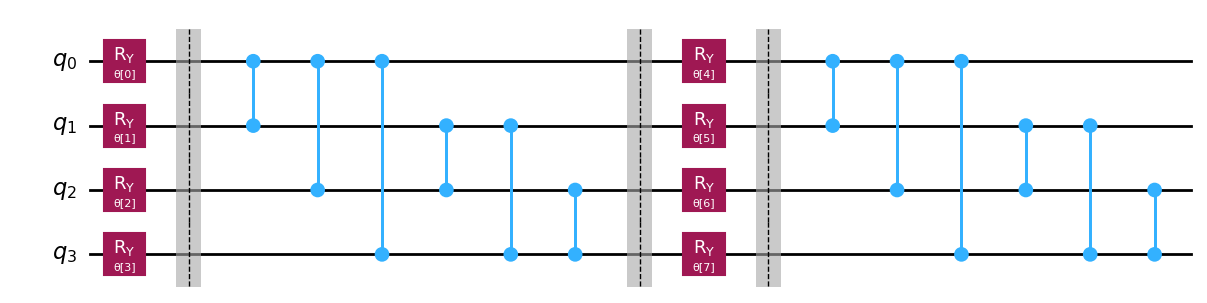

In [101]:
# Define the ansatz circuit
ansatz = TwoLocal(
    num_qubits=4,
    reps=2,
    entanglement='full',
    insert_barriers=True,
    rotation_blocks=['ry'],
    entanglement_blocks=['cz'],
    skip_final_rotation_layer=True
)

ansatz.decompose().draw(output='mpl')

In [27]:
# Set seed for reproducibility
np.random.seed(123)
param_vals = [np.random.random(ansatz.num_parameters)]
print(f"Parameter values: {param_vals}")

estimator = Estimator()

# Parameter shift rule
ps_grad = ParamShiftEstimatorGradient(estimator=estimator)
ps_grad_result = ps_grad.run(circuits=ansatz, observables=obj_op, parameter_values=param_vals).result()
print(f"Gradients from parameter shift rule: {ps_grad_result.gradients}")

# Linear combination of unitaries
lcu_grad = LinCombEstimatorGradient(estimator=estimator)
lcu_grad_result = lcu_grad.run(circuits=ansatz, observables=obj_op, parameter_values=param_vals).result()
print(f"Gradients from linear combination of unitaries: {lcu_grad_result.gradients}")

Parameter values: [array([0.69646919, 0.28613933, 0.22685145, 0.55131477, 0.71946897,
       0.42310646, 0.9807642 , 0.68482974])]
Gradients from parameter shift rule: [array([ 0.02647177, -0.07236736, -0.1457501 , -0.28929474, -0.08747353,
       -0.05184144, -0.77564701, -0.09262169])]
Gradients from linear combination of unitaries: [array([ 0.02647177, -0.07236736, -0.1457501 , -0.28929474, -0.08747353,
       -0.05184144, -0.77564701, -0.09262169])]


In [40]:
unperturbed_params = [np.random.random(ansatz.num_parameters)]
print(f"Parameter values: {unperturbed_params}")
[lcu_grad.run(circuits=[ansatz] * len(unperturbed_params), observables=constr_op, parameter_values=unperturbed_params).result().gradients for constr_op in constr_ops]

Parameter values: [array([0.62724897, 0.72341636, 0.01612921, 0.59443188, 0.55678519,
       0.15895964, 0.15307052, 0.69552953])]


[[array([-1.33304696, -3.60521918, -0.12372871, -4.81465762, -3.55513443,
         -0.02309854, -0.52760137, -4.79243727])],
 [array([-2.23813769e+00, -2.72663991e+00, -4.98027801e-02, -6.33411004e+00,
          3.88578059e-16,  3.33066907e-16, -1.38777878e-16, -6.01663027e+00])],
 [array([-2.12536383e+00, -2.62763705e+00, -2.90166941e-01, -2.32177691e+00,
         -2.70616862e-16, -2.24659957e-01, -4.96826393e-01, -2.23244329e+00])]]

In [127]:
# VQEC (Variational Quantum Eigensolver with Constraints) workflow with perturbed primal-dual method
# np.random.seed(123)

param_perturb_step = 0.05
dual_perturb_step = 0.05
max_iter = 500
tol = 1e-5
# Initialize the parameters and dual variables
unperturbed_params = [np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)]
unperturbed_dual_vars = np.array([0.1] * len(constr_ops))
print(f"Initial parameters: {unperturbed_params}")
print(f"Initial dual variables: {unperturbed_dual_vars}")

energies = [get_expectation(obj_op, ansatz, unperturbed_params)]
constraints_1 = [get_expectation(constr_op_1, ansatz, unperturbed_params)]
constraints_2 = [get_expectation(constr_op_2, ansatz, unperturbed_params)]
constraints_3 = [get_expectation(constr_op_3, ansatz, unperturbed_params)]
# Run the VQEC workflow
for i in tqdm(range(max_iter)):
    # Compute gradients for the objective and constraint operators
    obj_grad = (
        lcu_grad.run(
            circuits=ansatz, observables=obj_op, parameter_values=unperturbed_params
        )
        .result()
        .gradients
    )
    constr_grads = np.array(
        [
            lcu_grad.run(
                circuits=ansatz,
                observables=constr_op,
                parameter_values=unperturbed_params,
            )
            .result()
            .gradients
            for constr_op in constr_ops
        ]
    )
    # Compute the perturbed parameters
    param_perturbations = (
        np.array(
            [
                unperturbed_dual_var * constr_grad
                for unperturbed_dual_var, constr_grad in zip(
                    unperturbed_dual_vars, constr_grads
                )
            ]
        ).sum(axis=0)
        + obj_grad
    )
    # print(f"Param perturbations at iteration {i+1}: {param_perturbations}")
    perturbed_params = unperturbed_params - param_perturb_step * param_perturbations
    # print(f"Perturbed parameters at iteration {i+1}: {perturbed_params}")

    # Compute the perturbed dual variables
    dual_var_perturbations = np.array(
        [
            get_expectation(constr_op, ansatz, unperturbed_params)
            for constr_op in constr_ops
        ]
    )
    # print(f"Dual var perturbations at iteration {i+1}: {dual_var_perturbations}")
    perturbed_dual_vars = np.maximum(
        unperturbed_dual_vars + dual_perturb_step * dual_var_perturbations, 0
    )
    # print(f"Perturbed dual variables at iteration {i+1}: {perturbed_dual_vars}")

    # Set up the update step sizes
    param_update_step = 0.02 * 0.99**i
    dual_var_update_step = 0.02 * 0.99**i

    # Compute the updated parameters
    param_updates = (
        np.array(
            [
                perturbed_dual_var * constr_grad
                for perturbed_dual_var, constr_grad in zip(
                    perturbed_dual_vars, constr_grads
                )
            ]
        ).sum(axis=0)
        + obj_grad
    )
    # print(f"Param updates at iteration {i+1}: {param_updates}")
    updated_params = unperturbed_params - param_update_step * param_updates
    # print(f"Updated parameters at iteration {i+1}: {updated_params}")

    # Compute the updated dual variables
    dual_var_updates = np.array(
        [get_expectation(constr_op, ansatz, perturbed_params) for constr_op in constr_ops]
    )
    # print(f"Dual var updates at iteration {i+1}: {dual_var_updates}")
    updated_dual_vars = np.maximum(
        unperturbed_dual_vars + dual_var_update_step * dual_var_updates, 0
    )
    # print(f"Updated dual variables at iteration {i+1}: {updated_dual_vars}")

    # Compute the energy at the updated parameters
    energies.append(get_expectation(obj_op, ansatz, updated_params))
    constraints_1.append(get_expectation(constr_op_1, ansatz, updated_params))
    constraints_2.append(get_expectation(constr_op_2, ansatz, updated_params))
    constraints_3.append(get_expectation(constr_op_3, ansatz, updated_params))

    # Check for convergence
    # if (
    #     np.linalg.norm(updated_params - unperturbed_params)
    #     / np.linalg.norm(unperturbed_params)
    #     < tol
    # ):
    if np.abs(energies[-1] - energies[-2]) / np.abs(energies[-2]) < tol:
        print(f"Converged after {i+1} iterations")
        break

    # Update the parameters and dual variables
    unperturbed_params = updated_params
    unperturbed_dual_vars = updated_dual_vars

Initial parameters: [array([1.91491428, 2.50187443, 4.42938697, 6.25402179, 2.23627905,
       4.79122922, 3.72704049, 4.34609058])]
Initial dual variables: [0.1 0.1 0.1]


100%|██████████| 500/500 [00:16<00:00, 30.26it/s]


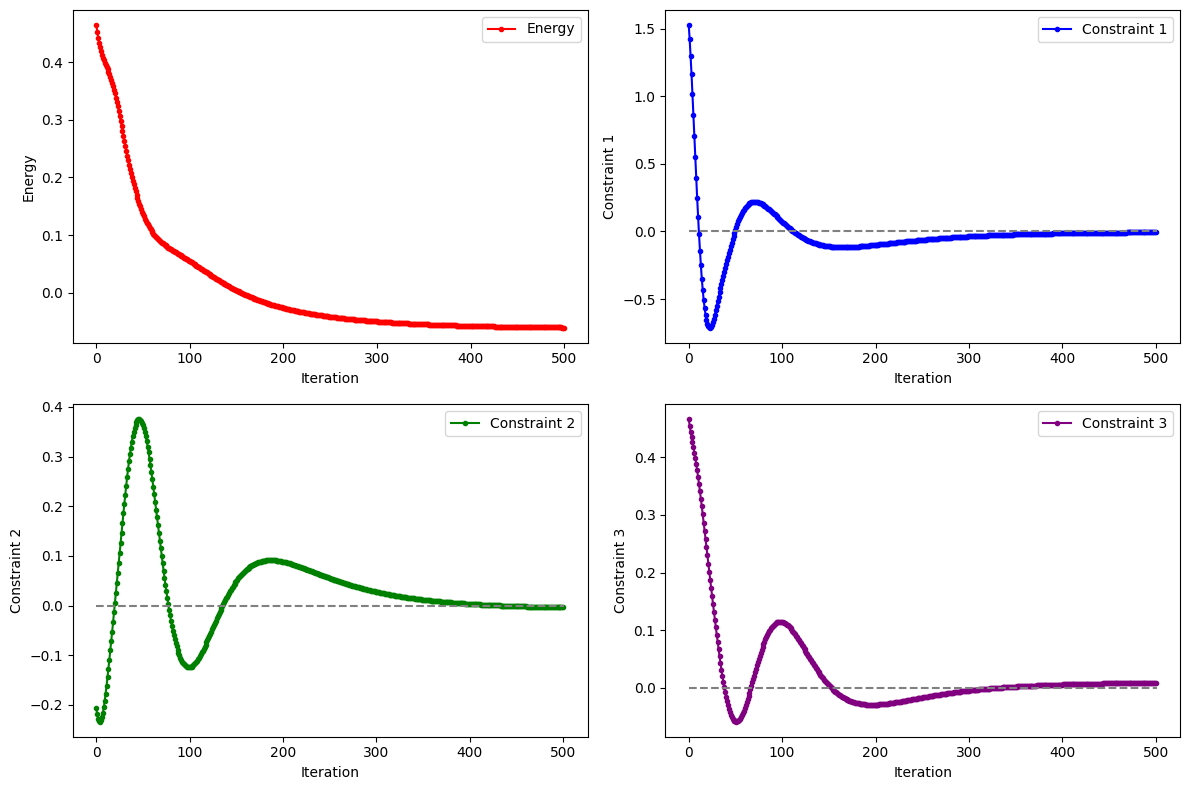

In [131]:
# Plot the energy and constraints
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(energies, label="Energy", color="red", marker=".")
axes[0, 0].set_ylabel("Energy")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].legend()
axes[0, 1].plot(constraints_1, label="Constraint 1", color="blue", marker=".")
axes[0, 1].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[0, 1].set_ylabel("Constraint 1")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].legend()
axes[1, 0].plot(constraints_2, label="Constraint 2", color="green", marker=".")
axes[1, 0].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[1, 0].set_ylabel("Constraint 2")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].legend()
axes[1, 1].plot(constraints_3, label="Constraint 3", color="purple", marker=".")
axes[1, 1].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[1, 1].set_ylabel("Constraint 3")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].legend()
plt.tight_layout()
plt.show()


TODO:
- Find the optimal solution by classical solver to assess the optimality of the variational solution.
- Hyperparameter tuning for the variational solution: $\nu_\theta$, $\nu_\lambda$, $\mu_\theta^t$, and $\mu_\lambda^t$.